# DUP — Current Batch Load and Anomaly Detection

| | |
|---|---|
| **Notebook** | `DUP_current_batch_load.ipynb` |
| **Description** | Processes current Duplicate QC batch data and evaluates analytical precision against the historical reference model. |
| **Author** | Rob Clark |
| **Created** | September 2026 / Semester 2 |
| **QC Type** | Duplicate |

## Change History

| Date | Author | Description |
|---|---|---|
| 2026-09-07 | R.Clark | (T32-144) Created Current Batch Load notebook and established workflow for evaluating Duplicate QC observations against the persisted historical reference model. |

## Purpose

This notebook processes a current batch of Duplicate QC observations and evaluates their analytical behaviour against the persisted historical Duplicate reference model.

The workflow will:

1. Load and validate current batch data.
2. Select and pair Duplicate QC observations.
3. Calculate precision features including **Mean Concentration** and **RPD**.
4. Load the persisted historical Duplicate reference model.
5. Map current observations to analyte-specific historical reference values.
6. Compare current RPD against historical **Q95** and **Limiting Repeatability** thresholds.
7. Identify and rank potential anomalies for review.

The current batch is **not used to fit or modify the historical model**. It is evaluated against the previously established historical reference.


In [1]:
# =============================================================================
# Imports and configuration
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------------
# Repository paths
# -----------------------------------------------------------------------------

DATA_DIR = Path("../data")
RAW_DATA_DIR = DATA_DIR / "raw"
REFERENCE_DATA_DIR = DATA_DIR / "reference"

CURRENT_BATCH_FILE = RAW_DATA_DIR / "ResultSet.csv"
REFERENCE_MODEL_FILE = (
    REFERENCE_DATA_DIR / "DUP_historical_reference_model.csv"
)


# -----------------------------------------------------------------------------
# Confirm configuration
# -----------------------------------------------------------------------------

print(f"Current batch source : {CURRENT_BATCH_FILE}")
print(f"Reference model      : {REFERENCE_MODEL_FILE}")


Current batch source : ..\data\raw\ResultSet.csv
Reference model      : ..\data\reference\DUP_historical_reference_model.csv


In [2]:
# =============================================================================
# Load current batch data
# =============================================================================

df = pd.read_csv(
    CURRENT_BATCH_FILE,
    dtype={
        "INSTRUMENT_ID": "string"
    }
)

print(f"Rows loaded: {len(df):,}")
print(f"Columns: {len(df.columns)}")

df.head()


Rows loaded: 99,999
Columns: 27


,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,...,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,<NA>
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,<NA>
2,Replicate,Sample,Sample,TSV_LB0016663011,1492.268392,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,NaN,Warning,...,NaN,10,1.25,15.0,1.25,NaN,1385.198107,MG_KG,NaN,<NA>
3,Replicate,Sample,Sample,TSV_LB0016663011,18.525452,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,NaN,Pass,...,NaN,10,5.00,15.0,5.00,NaN,16.334782,MG_KG,NaN,<NA>
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperWarning,NaN,...,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,<NA>


In [3]:
# =============================================================================
# Select Duplicate QC observations
# =============================================================================

df_dup = (
    df[
        (df["ANALYTICAL_TYPE"] == "Duplicate")
        & (df["STD_LOT_CODE"] == "Sample")
        & (df["STD_CODE"] == "Sample")
    ]
    .copy()
)

print(f"Duplicate rows selected: {len(df_dup):,}")
print(f"Jobs represented: {df_dup['JOB_CODE'].nunique():,}")
print(f"Analytes represented: {df_dup['ANALYTE_CODE'].nunique():,}")
print(f"Schemes represented: {df_dup['SCHEME_CODE'].nunique():,}")

print("\nDuplicate rows by scheme:")
display(
    df_dup["SCHEME_CODE"]
    .value_counts(dropna=False)
    .to_frame("ROWS")
)

df_dup.head()


Duplicate rows selected: 5,075
Jobs represented: 47
Analytes represented: 41
Schemes represented: 1

Duplicate rows by scheme:


,ROWS
SCHEME_CODE,
GE_ICP40Q12,5075


,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,...,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
19307,Duplicate,Sample,Sample,TSV_LB0007353557,2.185365,2021-05-10 11:39:33.000000,GE_ICP40Q12,TA,NaN,Pass,...,NaN,10,12.5,15.0,12.5,NaN,3.378640,MG_KG,NaN,<NA>
19308,Duplicate,Sample,Sample,TSV_LB0007353557,0.801886,2021-05-10 11:39:33.000000,GE_ICP40Q12,TA,NaN,Pass,...,NaN,10,12.5,15.0,12.5,NaN,-0.746270,MG_KG,NaN,<NA>
19309,Duplicate,Sample,Sample,TSV_LB0007353557,1.260273,2021-05-10 11:39:33.000000,GE_ICP40Q12,TA,NaN,Pass,...,NaN,10,12.5,15.0,12.5,NaN,1.879069,MG_KG,NaN,<NA>
19323,Duplicate,Sample,Sample,TSV_LB0007353557,-2.010870,2021-05-10 11:38:57.000000,GE_ICP40Q12,TA,NaN,Pass,...,NaN,10,12.5,15.0,12.5,NaN,-3.129188,MG_KG,NaN,<NA>
19324,Duplicate,Sample,Sample,TSV_LB0007353557,-3.709679,2021-05-10 11:38:57.000000,GE_ICP40Q12,TA,NaN,Pass,...,NaN,10,12.5,15.0,12.5,NaN,-2.185186,MG_KG,NaN,<NA>


In [4]:
# =============================================================================
# Build current Duplicate precision dataset
# =============================================================================

# Count Duplicate rows that cannot be linked to an analyte-specific
# historical reference model
missing_analyte_rows = (
    df_dup["ANALYTE_CODE"]
    .isna()
    .sum()
)

# Retain only Duplicate observations with a valid analyte code
current_dup_df = (
    df_dup[
        df_dup["ANALYTE_CODE"].notna()
    ][
        [
            "JOB_CODE",
            "ANALYSED_DATE",
            "ANALYTE_CODE",
            "SCHEME_CODE",
            "PARENT_NUMERIC_FINAL_VALUE",
            "NUMERIC_FINAL_VALUE",
            "STAT_DL_DUP_VALUE",
            "LIM_REP_DUP_VALUE",
            "PRECISION_STATUS",
            "UNIT_CODE"
        ]
    ]
    .copy()
)

# -----------------------------------------------------------------------------
# Derive precision features
# -----------------------------------------------------------------------------

# Absolute difference between original and Duplicate result
current_dup_df["ABS_DIFF"] = abs(
    current_dup_df["NUMERIC_FINAL_VALUE"]
    - current_dup_df["PARENT_NUMERIC_FINAL_VALUE"]
)

# Mean concentration of the paired results
current_dup_df["MEAN_CONC"] = (
    current_dup_df["NUMERIC_FINAL_VALUE"]
    + current_dup_df["PARENT_NUMERIC_FINAL_VALUE"]
) / 2

# Relative Percent Difference
current_dup_df["RPD"] = np.where(
    (
        current_dup_df["NUMERIC_FINAL_VALUE"]
        + current_dup_df["PARENT_NUMERIC_FINAL_VALUE"]
    ) != 0,
    (
        current_dup_df["ABS_DIFF"]
        / current_dup_df["MEAN_CONC"]
        * 100
    ),
    np.nan
)

# Round RPD for reporting consistency
current_dup_df["RPD"] = (
    current_dup_df["RPD"]
    .round(2)
)

# -----------------------------------------------------------------------------
# Reorder columns for downstream scoring
# -----------------------------------------------------------------------------

current_dup_df = current_dup_df[
    [
        "JOB_CODE",
        "ANALYSED_DATE",
        "ANALYTE_CODE",
        "SCHEME_CODE",
        "PARENT_NUMERIC_FINAL_VALUE",
        "NUMERIC_FINAL_VALUE",
        "MEAN_CONC",
        "ABS_DIFF",
        "RPD",
        "STAT_DL_DUP_VALUE",
        "LIM_REP_DUP_VALUE",
        "PRECISION_STATUS",
        "UNIT_CODE"
    ]
]

# -----------------------------------------------------------------------------
# Confirm prepared dataset
# -----------------------------------------------------------------------------

print(f"Duplicate observations available: {len(df_dup):,}")
print(f"Excluded missing ANALYTE_CODE:    {missing_analyte_rows:,}")
print(f"Current Duplicate observations:   {len(current_dup_df):,}")

print(
    f"Observations with paired parent value: "
    f"{current_dup_df['PARENT_NUMERIC_FINAL_VALUE'].notna().sum():,}"
)

print(
    f"Analytes represented: "
    f"{current_dup_df['ANALYTE_CODE'].nunique():,}"
)

current_dup_df.head(20)


Duplicate observations available: 5,075
Excluded missing ANALYTE_CODE:    136
Current Duplicate observations:   4,939
Observations with paired parent value: 4,939
Analytes represented: 41


,JOB_CODE,ANALYSED_DATE,ANALYTE_CODE,SCHEME_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,MEAN_CONC,ABS_DIFF,RPD,STAT_DL_DUP_VALUE,LIM_REP_DUP_VALUE,PRECISION_STATUS,UNIT_CODE
19307,TSV_LB0007353557,2021-05-10 11:39:33.000000,TA,GE_ICP40Q12,3.378640,2.185365,2.782003,1.193275,42.89,12.500,15.0,Pass,MG_KG
19308,TSV_LB0007353557,2021-05-10 11:39:33.000000,TA,GE_ICP40Q12,-0.746270,0.801886,0.027808,1.548156,5567.32,12.500,15.0,Pass,MG_KG
19309,TSV_LB0007353557,2021-05-10 11:39:33.000000,TA,GE_ICP40Q12,1.879069,1.260273,1.569671,0.618796,39.42,12.500,15.0,Pass,MG_KG
19323,TSV_LB0007353557,2021-05-10 11:38:57.000000,TA,GE_ICP40Q12,-3.129188,-2.010870,-2.570029,1.118317,-43.51,12.500,15.0,Pass,MG_KG
19324,TSV_LB0007353557,2021-05-10 11:38:57.000000,TA,GE_ICP40Q12,-2.185186,-3.709679,-2.947432,1.524493,-51.72,12.500,15.0,Pass,MG_KG
19330,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,-4.130237,5.205476,0.537619,9.335714,1736.49,25.000,15.0,Pass,MG_KG
19333,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,2.379626,3.537630,2.958628,1.158004,39.14,25.000,15.0,Pass,MG_KG
19337,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,2.995021,-5.698118,-1.351549,8.693140,-643.20,25.000,15.0,Pass,MG_KG
19339,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,-1.864082,-2.273175,-2.068629,0.409093,-19.78,25.000,15.0,Pass,MG_KG
19343,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,1.148321,1.956517,1.552419,0.808196,52.06,25.000,15.0,Pass,MG_KG


In [5]:
# =============================================================================
# Apply current Duplicate scoring eligibility rules
# =============================================================================

current_dup_score_df = (
    current_dup_df[
        current_dup_df["MEAN_CONC"].notna()
        & current_dup_df["RPD"].notna()
        & (current_dup_df["MEAN_CONC"] > 0)
    ]
    .copy()
)

print(f"Current Duplicate observations: {len(current_dup_df):,}")
print(f"Eligible for reference scoring: {len(current_dup_score_df):,}")
print(
    f"Excluded from scoring: "
    f"{len(current_dup_df) - len(current_dup_score_df):,}"
)

print(
    f"Analytes eligible for scoring: "
    f"{current_dup_score_df['ANALYTE_CODE'].nunique()}"
)

current_dup_score_df.head(20)


Current Duplicate observations: 4,939
Eligible for reference scoring: 4,437
Excluded from scoring: 502
Analytes eligible for scoring: 41


,JOB_CODE,ANALYSED_DATE,ANALYTE_CODE,SCHEME_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,MEAN_CONC,ABS_DIFF,RPD,STAT_DL_DUP_VALUE,LIM_REP_DUP_VALUE,PRECISION_STATUS,UNIT_CODE
19307,TSV_LB0007353557,2021-05-10 11:39:33.000000,TA,GE_ICP40Q12,3.378640,2.185365,2.782003,1.193275,42.89,12.500,15.0,Pass,MG_KG
19308,TSV_LB0007353557,2021-05-10 11:39:33.000000,TA,GE_ICP40Q12,-0.746270,0.801886,0.027808,1.548156,5567.32,12.500,15.0,Pass,MG_KG
19309,TSV_LB0007353557,2021-05-10 11:39:33.000000,TA,GE_ICP40Q12,1.879069,1.260273,1.569671,0.618796,39.42,12.500,15.0,Pass,MG_KG
19330,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,-4.130237,5.205476,0.537619,9.335714,1736.49,25.000,15.0,Pass,MG_KG
19333,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,2.379626,3.537630,2.958628,1.158004,39.14,25.000,15.0,Pass,MG_KG
19343,TSV_LB0007353557,2021-05-10 11:38:44.000000,TE,GE_ICP40Q12,1.148321,1.956517,1.552419,0.808196,52.06,25.000,15.0,Pass,MG_KG
19358,TSV_LB0007353557,2021-05-10 11:34:57.000000,MO,GE_ICP40Q12,1.975463,1.891936,1.933700,0.083527,4.32,2.500,15.0,Pass,MG_KG
19361,TSV_LB0007353557,2021-05-10 11:34:57.000000,MO,GE_ICP40Q12,1.236364,0.896196,1.066280,0.340168,31.90,2.500,15.0,Pass,MG_KG
19365,TSV_LB0007353557,2021-05-10 11:34:57.000000,MO,GE_ICP40Q12,1.889768,1.536987,1.713377,0.352781,20.59,2.500,15.0,Pass,MG_KG
19366,TSV_LB0007353557,2021-05-10 11:34:57.000000,MO,GE_ICP40Q12,2.219903,5.282440,3.751172,3.062537,81.64,2.500,15.0,Warning,MG_KG


In [6]:
# =============================================================================
# Load persisted Duplicate historical reference model
# =============================================================================

REFERENCE_MODEL_FILE = "../data/reference/DUP_historical_reference_model.csv"

reference_model_df = pd.read_csv(
    REFERENCE_MODEL_FILE
)

print(f"Reference model rows: {len(reference_model_df):,}")
print(
    f"Reference analytes: "
    f"{reference_model_df['ANALYTE_CODE'].nunique():,}"
)

print("\nReference model columns:")
print(", ".join(reference_model_df.columns))

reference_model_df.head()


Reference model rows: 12,300
Reference analytes: 41

Reference model columns:
ANALYTE_CODE, LOG_MEAN_CONC, MEAN_CONC, Q25, Q50, Q75, Q95, STAT_DL_DUP_VALUE, LIM_REP_DUP_VALUE, ALLOWABLE_RPD


,ANALYTE_CODE,LOG_MEAN_CONC,MEAN_CONC,Q25,Q50,Q75,Q95,STAT_DL_DUP_VALUE,LIM_REP_DUP_VALUE,ALLOWABLE_RPD
0,AG,-2.246569,0.005668,1285.710000,1285.710006,2678.039991,2144.041928,1.25,15.0,22068.571428
1,AG,-2.236281,0.005804,1262.846778,1264.871479,2633.105281,2143.103373,1.25,15.0,21552.302101
2,AG,-2.225994,0.005943,1240.257721,1244.270097,2588.694894,2141.870919,1.25,15.0,21048.118528
3,AG,-2.215706,0.006085,1217.941185,1223.904482,2544.805718,2140.347581,1.25,15.0,20555.737782
4,AG,-2.205418,0.006231,1195.895526,1203.773254,2501.434639,2138.536369,1.25,15.0,20074.883564


In [7]:
# =============================================================================
# Validate current Duplicate analytes against historical reference model
# =============================================================================

current_analytes = set(
    current_dup_score_df["ANALYTE_CODE"].dropna().unique()
)

reference_analytes = set(
    reference_model_df["ANALYTE_CODE"].dropna().unique()
)

matched_analytes = current_analytes & reference_analytes
missing_analytes = current_analytes - reference_analytes
unused_reference_analytes = reference_analytes - current_analytes

print(f"Current analytes eligible for scoring: {len(current_analytes):,}")
print(f"Historical reference analytes:       {len(reference_analytes):,}")
print(f"Matched analytes:                    {len(matched_analytes):,}")
print(f"Missing historical reference:        {len(missing_analytes):,}")

if missing_analytes:
    print(
        "\nCurrent analytes without a historical reference model:"
    )
    print(", ".join(sorted(missing_analytes)))
else:
    print(
        "\nAll current Duplicate analytes have a historical reference model."
    )

if unused_reference_analytes:
    print(
        "\nHistorical analytes not represented in the current batch:"
    )
    print(", ".join(sorted(unused_reference_analytes)))
    

Current analytes eligible for scoring: 41
Historical reference analytes:       41
Matched analytes:                    41
Missing historical reference:        0

All current Duplicate analytes have a historical reference model.


In [8]:
# =============================================================================
# Interpolate historical reference values for current Duplicate observations
# =============================================================================

# Log-transform current mean concentration
current_dup_score_df["LOG_MEAN_CONC"] = np.log10(
    current_dup_score_df["MEAN_CONC"]
)

scored_tables = []

for analyte, current_group in current_dup_score_df.groupby("ANALYTE_CODE"):

    # Historical reference curve for this analyte
    ref_group = (
        reference_model_df[
            reference_model_df["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("LOG_MEAN_CONC")
    )

    # Current observations for this analyte
    scored_group = current_group.copy()

    x_ref = ref_group["LOG_MEAN_CONC"].to_numpy()
    x_current = scored_group["LOG_MEAN_CONC"].to_numpy()

    # ---------------------------------------------------------
    # Identify whether current observations fall within the
    # historical concentration range for this analyte
    # ---------------------------------------------------------

    ref_min = x_ref.min()
    ref_max = x_ref.max()

    scored_group["WITHIN_REFERENCE_RANGE"] = (
        (scored_group["LOG_MEAN_CONC"] >= ref_min)
        & (scored_group["LOG_MEAN_CONC"] <= ref_max)
    )

    # ---------------------------------------------------------
    # Interpolate historical quantiles and allowable RPD
    # ---------------------------------------------------------

    for col in ["Q25", "Q50", "Q75", "Q95", "ALLOWABLE_RPD"]:

        scored_group[f"REF_{col}"] = np.interp(
            x_current,
            x_ref,
            ref_group[col].to_numpy()
        )

    scored_tables.append(scored_group)

# ---------------------------------------------------------
# Combine all analytes
# ---------------------------------------------------------

current_dup_scored_df = pd.concat(
    scored_tables,
    ignore_index=True
)

# ---------------------------------------------------------
# Confirm scoring output
# ---------------------------------------------------------

print(
    f"Current Duplicate observations scored: "
    f"{len(current_dup_scored_df):,}"
)

print(
    f"Within historical concentration range: "
    f"{current_dup_scored_df['WITHIN_REFERENCE_RANGE'].sum():,}"
)

print(
    f"Outside historical concentration range: "
    f"{(~current_dup_scored_df['WITHIN_REFERENCE_RANGE']).sum():,}"
)

current_dup_scored_df[
    [
        "JOB_CODE",
        "ANALYTE_CODE",
        "MEAN_CONC",
        "RPD",
        "WITHIN_REFERENCE_RANGE",
        "REF_Q50",
        "REF_Q95",
        "REF_ALLOWABLE_RPD"
    ]
].head(20)


Current Duplicate observations scored: 4,437
Within historical concentration range: 4,430
Outside historical concentration range: 7


,JOB_CODE,ANALYTE_CODE,MEAN_CONC,RPD,WITHIN_REFERENCE_RANGE,REF_Q50,REF_Q95,REF_ALLOWABLE_RPD
0,TSV_LB0007353672,AG,0.188884,130.57,True,50.901692,402.489623,676.783710
1,TSV_LB0007353557,AG,0.012395,546.99,True,715.270657,1974.026926,10099.426840
2,TSV_LB0007353441,AG,0.288318,59.25,True,41.409058,219.455036,448.562686
3,TSV_LB0007353441,AG,0.386792,68.29,True,37.104288,129.296587,338.188823
4,TSV_LB0007353441,AG,0.279616,11.06,True,41.899700,230.765743,462.071534
5,TSV_LB0007341084,AG,0.053904,128.99,True,173.569402,1158.246446,2333.972090
6,TSV_LB0007341084,AG,0.888665,7.09,True,23.294288,35.234341,155.669775
7,TSV_LB0007340966,AG,0.184223,122.06,True,51.728106,414.959896,693.532741
8,TSV_LB0007340966,AG,0.330712,9.34,True,39.372343,173.144699,392.995561
9,TSV_LB0007340966,AG,0.246186,46.41,True,44.174100,281.188726,522.768834


In [9]:
# =============================================================================
# Classify current Duplicate observations against historical references
# =============================================================================

# -----------------------------------------------------------------------------
# Historical anomaly
#
# Current RPD is above the historical 95th percentile AND the observation
# lies within the concentration range represented by the historical model.
# -----------------------------------------------------------------------------

current_dup_scored_df["EXCEEDS_Q95"] = (
    current_dup_scored_df["WITHIN_REFERENCE_RANGE"]
    & (
        current_dup_scored_df["RPD"]
        > current_dup_scored_df["REF_Q95"]
    )
)

# -----------------------------------------------------------------------------
# Limiting Repeatability anomaly
#
# Current RPD is above Datamine's allowable RPD threshold.
# This rule is evaluated independently of the empirical historical
# concentration range.
# -----------------------------------------------------------------------------

current_dup_scored_df["EXCEEDS_ALLOWABLE_RPD"] = (
    current_dup_scored_df["RPD"]
    > current_dup_scored_df["REF_ALLOWABLE_RPD"]
)

# -----------------------------------------------------------------------------
# Exceedance metrics
# -----------------------------------------------------------------------------

# Absolute exceedance above historical Q95
current_dup_scored_df["Q95_EXCESS"] = (
    current_dup_scored_df["RPD"]
    - current_dup_scored_df["REF_Q95"]
).clip(lower=0)

# Historical Q95 exceedance is not considered valid outside the
# historical concentration range
current_dup_scored_df.loc[
    ~current_dup_scored_df["WITHIN_REFERENCE_RANGE"],
    "Q95_EXCESS"
] = 0

# Absolute exceedance above Limiting Repeatability
current_dup_scored_df["ALLOWABLE_EXCESS"] = (
    current_dup_scored_df["RPD"]
    - current_dup_scored_df["REF_ALLOWABLE_RPD"]
).clip(lower=0)

# Relative severity compared with Limiting Repeatability
current_dup_scored_df["ALLOWABLE_RATIO"] = (
    current_dup_scored_df["RPD"]
    / current_dup_scored_df["REF_ALLOWABLE_RPD"]
)

# -----------------------------------------------------------------------------
# Four-way anomaly classification
#
# BOTH_EXCEEDED     = exceeds historical Q95 AND Limiting Repeatability
# LIMIT_EXCEEDED    = exceeds Limiting Repeatability only
# HISTORICAL_HIGH   = exceeds historical Q95 only
# NORMAL            = exceeds neither threshold
# -----------------------------------------------------------------------------

current_dup_scored_df["ANOMALY_CLASS"] = np.select(
    [
        (
            current_dup_scored_df["EXCEEDS_Q95"]
            & current_dup_scored_df["EXCEEDS_ALLOWABLE_RPD"]
        ),
        current_dup_scored_df["EXCEEDS_ALLOWABLE_RPD"],
        current_dup_scored_df["EXCEEDS_Q95"]
    ],
    [
        "BOTH_EXCEEDED",
        "LIMIT_EXCEEDED",
        "HISTORICAL_HIGH"
    ],
    default="NORMAL"
)

# -----------------------------------------------------------------------------
# Confirm classification results
# -----------------------------------------------------------------------------

print(
    f"Above historical Q95: "
    f"{current_dup_scored_df['EXCEEDS_Q95'].sum():,}"
)

print(
    f"Above Limiting Repeatability: "
    f"{current_dup_scored_df['EXCEEDS_ALLOWABLE_RPD'].sum():,}"
)

print("\nAnomaly classification:")

display(
    current_dup_scored_df["ANOMALY_CLASS"]
    .value_counts()
    .to_frame("OBSERVATIONS")
)

# -----------------------------------------------------------------------------
# Preview classified observations
# -----------------------------------------------------------------------------

current_dup_scored_df[
    [
        "JOB_CODE",
        "ANALYTE_CODE",
        "MEAN_CONC",
        "RPD",
        "REF_Q95",
        "REF_ALLOWABLE_RPD",
        "WITHIN_REFERENCE_RANGE",
        "EXCEEDS_Q95",
        "EXCEEDS_ALLOWABLE_RPD",
        "Q95_EXCESS",
        "ALLOWABLE_EXCESS",
        "ALLOWABLE_RATIO",
        "ANOMALY_CLASS"
    ]
].head(20)


Above historical Q95: 367
Above Limiting Repeatability: 205

Anomaly classification:


,OBSERVATIONS
ANOMALY_CLASS,
NORMAL,3975
HISTORICAL_HIGH,257
BOTH_EXCEEDED,110
LIMIT_EXCEEDED,95


,JOB_CODE,ANALYTE_CODE,MEAN_CONC,RPD,REF_Q95,REF_ALLOWABLE_RPD,WITHIN_REFERENCE_RANGE,EXCEEDS_Q95,EXCEEDS_ALLOWABLE_RPD,Q95_EXCESS,ALLOWABLE_EXCESS,ALLOWABLE_RATIO,ANOMALY_CLASS
0,TSV_LB0007353672,AG,0.188884,130.57,402.489623,676.783710,True,False,False,0.000000,0.0,0.192927,NORMAL
1,TSV_LB0007353557,AG,0.012395,546.99,1974.026926,10099.426840,True,False,False,0.000000,0.0,0.054160,NORMAL
2,TSV_LB0007353441,AG,0.288318,59.25,219.455036,448.562686,True,False,False,0.000000,0.0,0.132089,NORMAL
3,TSV_LB0007353441,AG,0.386792,68.29,129.296587,338.188823,True,False,False,0.000000,0.0,0.201929,NORMAL
4,TSV_LB0007353441,AG,0.279616,11.06,230.765743,462.071534,True,False,False,0.000000,0.0,0.023936,NORMAL
5,TSV_LB0007341084,AG,0.053904,128.99,1158.246446,2333.972090,True,False,False,0.000000,0.0,0.055266,NORMAL
6,TSV_LB0007341084,AG,0.888665,7.09,35.234341,155.669775,True,False,False,0.000000,0.0,0.045545,NORMAL
7,TSV_LB0007340966,AG,0.184223,122.06,414.959896,693.532741,True,False,False,0.000000,0.0,0.175997,NORMAL
8,TSV_LB0007340966,AG,0.330712,9.34,173.144699,392.995561,True,False,False,0.000000,0.0,0.023766,NORMAL
9,TSV_LB0007340966,AG,0.246186,46.41,281.188726,522.768834,True,False,False,0.000000,0.0,0.088777,NORMAL


In [10]:
# =============================================================================
# Diagnose anomaly classifications by historical concentration range
# =============================================================================

# -----------------------------------------------------------------------------
# Summarise anomaly classifications inside and outside the concentration
# range represented by the historical reference model
# -----------------------------------------------------------------------------

range_classification = pd.crosstab(
    current_dup_scored_df["ANOMALY_CLASS"],
    current_dup_scored_df["WITHIN_REFERENCE_RANGE"],
    margins=True
)

# Rename Boolean columns for readability
range_classification = range_classification.rename(
    columns={
        False: "OUTSIDE_REFERENCE_RANGE",
        True: "WITHIN_REFERENCE_RANGE"
    }
)

display(range_classification)

# -----------------------------------------------------------------------------
# Population counts
# -----------------------------------------------------------------------------

within_range_mask = (
    current_dup_scored_df["WITHIN_REFERENCE_RANGE"]
)

outside_range_mask = (
    ~current_dup_scored_df["WITHIN_REFERENCE_RANGE"]
)

anomaly_mask = (
    current_dup_scored_df["ANOMALY_CLASS"] != "NORMAL"
)

print(
    f"\nObservations within historical concentration range: "
    f"{within_range_mask.sum():,}"
)

print(
    f"Observations outside historical concentration range: "
    f"{outside_range_mask.sum():,}"
)

print(
    f"\nAnomalies within historical concentration range: "
    f"{(within_range_mask & anomaly_mask).sum():,}"
)

print(
    f"Anomalies outside historical concentration range: "
    f"{(outside_range_mask & anomaly_mask).sum():,}"
)

# -----------------------------------------------------------------------------
# Validate historical classifications
#
# Historical Q95 classifications should only occur where the observation
# lies within the concentration range represented by the historical model.
# -----------------------------------------------------------------------------

invalid_historical_classification = (
    outside_range_mask
    & current_dup_scored_df["ANOMALY_CLASS"].isin(
        ["HISTORICAL_HIGH", "BOTH_EXCEEDED"]
    )
)

print(
    f"\nHistorical classifications outside reference range: "
    f"{invalid_historical_classification.sum():,}"
)


WITHIN_REFERENCE_RANGE,OUTSIDE_REFERENCE_RANGE,WITHIN_REFERENCE_RANGE,All
ANOMALY_CLASS,,,
BOTH_EXCEEDED,0,110,110
HISTORICAL_HIGH,0,257,257
LIMIT_EXCEEDED,4,91,95
NORMAL,3,3972,3975
All,7,4430,4437



Observations within historical concentration range: 4,430
Observations outside historical concentration range: 7

Anomalies within historical concentration range: 458
Anomalies outside historical concentration range: 4

Historical classifications outside reference range: 0


In [11]:
# =============================================================================
# Diagnostic: inspect observations outside historical reference range
# =============================================================================

outside_reference_df = (
    current_dup_scored_df[
        ~current_dup_scored_df["WITHIN_REFERENCE_RANGE"]
    ]
    [
        [
            "JOB_CODE",
            "ANALYSED_DATE",
            "ANALYTE_CODE",
            "SCHEME_CODE",
            "PARENT_NUMERIC_FINAL_VALUE",
            "NUMERIC_FINAL_VALUE",
            "MEAN_CONC",
            "RPD",
            "STAT_DL_DUP_VALUE",
            "LIM_REP_DUP_VALUE",
            "REF_Q95",
            "REF_ALLOWABLE_RPD",
            "EXCEEDS_Q95",
            "EXCEEDS_ALLOWABLE_RPD",
            "ANOMALY_CLASS"
        ]
    ]
    .sort_values(
        ["ANALYTE_CODE", "MEAN_CONC"]
    )
)

print(
    f"Observations outside historical reference range: "
    f"{len(outside_reference_df):,}"
)

display(outside_reference_df)


Observations outside historical reference range: 7


,JOB_CODE,ANALYSED_DATE,ANALYTE_CODE,SCHEME_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,MEAN_CONC,RPD,STAT_DL_DUP_VALUE,LIM_REP_DUP_VALUE,REF_Q95,REF_ALLOWABLE_RPD,EXCEEDS_Q95,EXCEEDS_ALLOWABLE_RPD,ANOMALY_CLASS
1248,TSV_LB0002875057,2020-07-30 11:01:18.000000,CU,GE_ICP40Q12,1.176047,0.070936,0.623491,177.25,1.25,15.0,30.915577,55.249293,False,True,LIMIT_EXCEEDED
1734,TSV_LB0004328823,2021-03-22 14:33:30.000000,LA,GE_ICP40Q12,1.411000,0.040800,0.725900,188.76,1.25,15.0,188.760000,187.200028,False,True,LIMIT_EXCEEDED
1765,TSV_LB0006483071,2021-05-07 13:03:18.000000,LI,GE_ICP40Q12,0.589372,1.059192,0.824282,57.00,2.50,15.0,60.490350,318.294237,False,False,NORMAL
3157,TSV_LB0004328823,2021-03-22 14:38:12.000000,SC,GE_ICP40Q12,0.095000,1.140000,0.617500,169.23,1.25,15.0,7.470000,117.784634,False,True,LIMIT_EXCEEDED
3452,TSV_LB0004328823,2020-11-04 06:08:17.000000,SR,GE_ICP40Q12,1.010000,0.012000,0.511000,195.30,1.25,15.0,10.870000,25.355326,False,True,LIMIT_EXCEEDED
3545,TSV_LB0002874933,2021-04-16 10:20:26.717000,TE,GE_ICP40Q12,80.620321,74.314815,77.467568,8.14,25.00,15.0,8.140000,47.271570,False,False,NORMAL
3920,TSV_LB0002815407,2021-05-03 19:55:06.000000,V,GE_ICP40Q12,602.088000,636.324000,619.206000,5.53,5.00,15.0,5.530000,15.807486,False,False,NORMAL


In [12]:
# =============================================================================
# Calculate anomaly severity measures
# =============================================================================

# -----------------------------------------------------------------------------
# Historical severity
#
# Ratio of observed RPD to historical Q95.
# Only meaningful where the observation lies within the historical
# concentration range represented by the reference model.
# -----------------------------------------------------------------------------

current_dup_scored_df["Q95_RATIO"] = np.where(
    current_dup_scored_df["WITHIN_REFERENCE_RANGE"]
    & (current_dup_scored_df["REF_Q95"] > 0),
    current_dup_scored_df["RPD"]
    / current_dup_scored_df["REF_Q95"],
    np.nan
)

# -----------------------------------------------------------------------------
# Limiting Repeatability severity
#
# Ratio of observed RPD to Datamine's allowable RPD threshold.
# A value > 1 indicates that the threshold has been exceeded.
# -----------------------------------------------------------------------------

current_dup_scored_df["ALLOWABLE_RATIO"] = np.where(
    current_dup_scored_df["REF_ALLOWABLE_RPD"] > 0,
    current_dup_scored_df["RPD"]
    / current_dup_scored_df["REF_ALLOWABLE_RPD"],
    np.nan
)

# -----------------------------------------------------------------------------
# Classification priority
#
# Provides an interpretable ordering of anomaly classes without introducing
# arbitrary weighting between the historical and operational thresholds.
# -----------------------------------------------------------------------------

class_priority = {
    "NORMAL": 0,
    "HISTORICAL_HIGH": 1,
    "LIMIT_EXCEEDED": 2,
    "BOTH_EXCEEDED": 3
}

current_dup_scored_df["CLASS_PRIORITY"] = (
    current_dup_scored_df["ANOMALY_CLASS"]
    .map(class_priority)
)

# -----------------------------------------------------------------------------
# Confirm severity measures
# -----------------------------------------------------------------------------

current_dup_scored_df[
    [
        "JOB_CODE",
        "ANALYTE_CODE",
        "MEAN_CONC",
        "RPD",
        "REF_Q95",
        "Q95_RATIO",
        "REF_ALLOWABLE_RPD",
        "ALLOWABLE_RATIO",
        "ANOMALY_CLASS",
        "CLASS_PRIORITY"
    ]
].head(20)


,JOB_CODE,ANALYTE_CODE,MEAN_CONC,RPD,REF_Q95,Q95_RATIO,REF_ALLOWABLE_RPD,ALLOWABLE_RATIO,ANOMALY_CLASS,CLASS_PRIORITY
0,TSV_LB0007353672,AG,0.188884,130.57,402.489623,0.324406,676.783710,0.192927,NORMAL,0
1,TSV_LB0007353557,AG,0.012395,546.99,1974.026926,0.277093,10099.426840,0.054160,NORMAL,0
2,TSV_LB0007353441,AG,0.288318,59.25,219.455036,0.269987,448.562686,0.132089,NORMAL,0
3,TSV_LB0007353441,AG,0.386792,68.29,129.296587,0.528166,338.188823,0.201929,NORMAL,0
4,TSV_LB0007353441,AG,0.279616,11.06,230.765743,0.047927,462.071534,0.023936,NORMAL,0
5,TSV_LB0007341084,AG,0.053904,128.99,1158.246446,0.111367,2333.972090,0.055266,NORMAL,0
6,TSV_LB0007341084,AG,0.888665,7.09,35.234341,0.201224,155.669775,0.045545,NORMAL,0
7,TSV_LB0007340966,AG,0.184223,122.06,414.959896,0.294149,693.532741,0.175997,NORMAL,0
8,TSV_LB0007340966,AG,0.330712,9.34,173.144699,0.053943,392.995561,0.023766,NORMAL,0
9,TSV_LB0007340966,AG,0.246186,46.41,281.188726,0.165049,522.768834,0.088777,NORMAL,0


In [27]:
# =============================================================================
# Rank Duplicate anomaly candidates by Job and Analyte
# =============================================================================

# -----------------------------------------------------------------------------
# Retain anomaly observations only
# -----------------------------------------------------------------------------

dup_anomaly_df = (
    current_dup_scored_df[
        current_dup_scored_df["ANOMALY_CLASS"] != "NORMAL"
    ]
    .copy()
)

# -----------------------------------------------------------------------------
# Calculate total scoreable observations for each Job x Analyte
#
# This provides context for the anomaly count so that, for example,
# 2 anomalies from 3 observations can be distinguished from
# 2 anomalies from 50 observations.
# -----------------------------------------------------------------------------

dup_total_summary_df = (
    current_dup_scored_df
    .groupby(
        [
            "JOB_CODE",
            "ANALYTE_CODE"
        ],
        as_index=False
    )
    .agg(
        TOTAL_OBSERVATION_COUNT=("ANOMALY_CLASS", "size")
    )
)

# -----------------------------------------------------------------------------
# Aggregate observation-level anomalies to Job x Analyte candidates
# -----------------------------------------------------------------------------

dup_anomaly_summary_df = (
    dup_anomaly_df
    .groupby(
        [
            "JOB_CODE",
            "ANALYTE_CODE"
        ],
        as_index=False
    )
    .agg(
        ANOMALY_COUNT=("ANOMALY_CLASS", "size"),

        MAX_CLASS_PRIORITY=("CLASS_PRIORITY", "max"),

        MAX_RPD=("RPD", "max"),

        MAX_Q95_RATIO=("Q95_RATIO", "max"),

        MAX_ALLOWABLE_RATIO=("ALLOWABLE_RATIO", "max"),

        Q95_EXCEED_COUNT=("EXCEEDS_Q95", "sum"),

        ALLOWABLE_EXCEED_COUNT=(
            "EXCEEDS_ALLOWABLE_RPD",
            "sum"
        ),

        BOTH_EXCEED_COUNT=(
            "ANOMALY_CLASS",
            lambda x: (x == "BOTH_EXCEEDED").sum()
        )
    )
)

# -----------------------------------------------------------------------------
# Add total observation context
# -----------------------------------------------------------------------------

dup_anomaly_summary_df = (
    dup_anomaly_summary_df
    .merge(
        dup_total_summary_df,
        on=[
            "JOB_CODE",
            "ANALYTE_CODE"
        ],
        how="left"
    )
)

# Percentage of scoreable observations classified as anomalous
dup_anomaly_summary_df["ANOMALY_RATE"] = (
    dup_anomaly_summary_df["ANOMALY_COUNT"]
    / dup_anomaly_summary_df["TOTAL_OBSERVATION_COUNT"]
)

# -----------------------------------------------------------------------------
# Recover the highest-severity anomaly class represented by each candidate
# -----------------------------------------------------------------------------

priority_class = {
    1: "HISTORICAL_HIGH",
    2: "LIMIT_EXCEEDED",
    3: "BOTH_EXCEEDED"
}

dup_anomaly_summary_df["MAX_ANOMALY_CLASS"] = (
    dup_anomaly_summary_df["MAX_CLASS_PRIORITY"]
    .map(priority_class)
)

# -----------------------------------------------------------------------------
# Rank candidates
#
# Ranking order:
#   1. Highest anomaly class
#   2. Number of observations exceeding both thresholds
#   3. Anomaly rate within Job x Analyte
#   4. Maximum Limiting Repeatability severity
#   5. Maximum historical Q95 severity
#   6. Total anomaly count
#
# The ranking remains deliberately interpretable rather than relying on
# an arbitrary weighted composite anomaly score.
# -----------------------------------------------------------------------------

dup_anomaly_summary_df = (
    dup_anomaly_summary_df
    .sort_values(
        [
            "MAX_CLASS_PRIORITY",
            "BOTH_EXCEED_COUNT",
            "ANOMALY_RATE",
            "MAX_ALLOWABLE_RATIO",
            "MAX_Q95_RATIO",
            "ANOMALY_COUNT"
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# Add sequential rank after sorting
dup_anomaly_summary_df["RANK"] = (
    np.arange(1, len(dup_anomaly_summary_df) + 1)
)

# -----------------------------------------------------------------------------
# Confirm ranking output
# -----------------------------------------------------------------------------

print(
    f"Anomalous Duplicate observations: "
    f"{len(dup_anomaly_df):,}"
)

print(
    f"Job x Analyte anomaly candidates: "
    f"{len(dup_anomaly_summary_df):,}"
)

print(
    f"Jobs containing anomaly candidates: "
    f"{dup_anomaly_summary_df['JOB_CODE'].nunique():,}"
)

# -----------------------------------------------------------------------------
# Preview highest-ranked candidates
# -----------------------------------------------------------------------------

display(
    dup_anomaly_summary_df[
        [
            "RANK",
            "JOB_CODE",
            "ANALYTE_CODE",
            "MAX_ANOMALY_CLASS",
            "ANOMALY_COUNT",
            "TOTAL_OBSERVATION_COUNT",
            "ANOMALY_RATE",
            "BOTH_EXCEED_COUNT",
            "Q95_EXCEED_COUNT",
            "ALLOWABLE_EXCEED_COUNT",
            "MAX_Q95_RATIO",
            "MAX_ALLOWABLE_RATIO",
            "MAX_RPD"
        ]
    ].head(30)
)


Anomalous Duplicate observations: 462
Job x Analyte anomaly candidates: 377
Jobs containing anomaly candidates: 41


,RANK,JOB_CODE,ANALYTE_CODE,MAX_ANOMALY_CLASS,ANOMALY_COUNT,TOTAL_OBSERVATION_COUNT,ANOMALY_RATE,BOTH_EXCEED_COUNT,Q95_EXCEED_COUNT,ALLOWABLE_EXCEED_COUNT,MAX_Q95_RATIO,MAX_ALLOWABLE_RATIO,MAX_RPD
0,1,TSV_LB0006483071,ZR,BOTH_EXCEEDED,3,3,1.000000,2,2,3,1.869498,9.556851,149.96
1,2,TSV_LB0006483071,HF,BOTH_EXCEEDED,3,3,1.000000,2,2,3,1.028132,1.755075,66.01
2,3,TSV_LB0004328823,NI,BOTH_EXCEEDED,2,4,0.500000,2,2,2,7.109358,8.809697,176.54
3,4,TSV_LB0004328823,FE,BOTH_EXCEEDED,2,4,0.500000,2,2,2,1.980588,6.329937,182.30
4,5,TSV_LB0004797270,CO,BOTH_EXCEEDED,2,4,0.500000,2,2,2,3.581341,5.069469,180.96
5,6,TSV_LB0004797270,AS,BOTH_EXCEEDED,1,1,1.000000,1,1,1,NaN,9.574448,204.75
6,7,TSV_LB0007353672,CR,BOTH_EXCEEDED,1,1,1.000000,1,1,1,1.000032,3.120331,55.78
7,8,TSV_LB0007353672,BA,BOTH_EXCEEDED,1,1,1.000000,1,1,1,4.332689,3.092176,47.81
8,9,TSV_LB0007353672,S,BOTH_EXCEEDED,1,1,1.000000,1,1,1,1.000001,2.630846,51.15
9,10,TSV_LB0006832499,AS,BOTH_EXCEEDED,3,3,1.000000,1,1,3,1.707586,2.514617,1403.40


In [30]:
# =============================================================================
# Load original historical Duplicate observations for visualisation
# =============================================================================

HISTORICAL_DUP_FILE = "../data/processed/duplicates_model.csv"

historical_dup_df = pd.read_csv(
    HISTORICAL_DUP_FILE
)

# -----------------------------------------------------------------------------
# Reproduce the historical reference population used to fit the model
# -----------------------------------------------------------------------------

accepted_statuses = [
    "Pass",
    "IgnoreFailure"
]

historical_reference_obs_df = (
    historical_dup_df[
        (historical_dup_df["RPD"] > 0)
        & (
            historical_dup_df["PRECISION_STATUS"]
            .isin(accepted_statuses)
        )
        & (historical_dup_df["MEAN_CONC"] > 0)
    ]
    .copy()
)

# -----------------------------------------------------------------------------
# Confirm historical observation population
# -----------------------------------------------------------------------------

print(
    f"Historical Duplicate observations available for plotting: "
    f"{len(historical_reference_obs_df):,}"
)

print(
    f"Historical analytes available: "
    f"{historical_reference_obs_df['ANALYTE_CODE'].nunique():,}"
)

historical_reference_obs_df.head()


Historical Duplicate observations available for plotting: 4,256
Historical analytes available: 41


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_DUP_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_DUP_VALUE,UNIT_CODE
0,2021-05-10 11:39:33.000000,TA,3.378640,2.185365,12.5,2.782003,1.193275,42.89,Pass,15.0,MG_KG
1,2021-05-10 11:39:33.000000,TA,-0.746270,0.801886,12.5,0.027808,1.548156,5567.32,Pass,15.0,MG_KG
2,2021-05-10 11:39:33.000000,TA,1.879069,1.260273,12.5,1.569671,0.618796,39.42,Pass,15.0,MG_KG
5,2021-05-10 11:38:44.000000,TE,-4.130237,5.205476,25.0,0.537619,9.335714,1736.49,Pass,15.0,MG_KG
6,2021-05-10 11:38:44.000000,TE,2.379626,3.537630,25.0,2.958628,1.158004,39.14,Pass,15.0,MG_KG


In [50]:
# =============================================================================
# Visualise current Duplicate candidate against historical reference model
# =============================================================================

# Reuse historical reference-model chart palette
OBS_COLOUR = "#4472C4"        # Historical observations "#5B9BD5"
QUANTILE_COLOUR = "#5B6573"   # Q25 and Q75
MEDIAN_COLOUR = "#1F4E79"     # Q50
P95_COLOUR = "#A33A3A"        # Q95
IQR_COLOUR = "#AFC6DB"        # Q25-Q75 band
LIMIT_COLOUR = "#7A3E00"      # Limiting Repeatability

# Current-load observation colour
CURRENT_COLOUR = "#E67E22"     # Orange


def plot_dup_candidate(
    job_code,
    analyte_code,
    show_historical_observations=True
):
    """
    Plot one current-batch Duplicate Job x Analyte candidate against the
    persisted historical reference model.

    Parameters
    ----------
    job_code : str
        Current batch JOB_CODE to visualise.

    analyte_code : str
        ANALYTE_CODE to visualise.

    show_historical_observations : bool, default True
        When True, display the original historical Duplicate observations
        behind the fitted historical reference model.
    """

    # -------------------------------------------------------------------------
    # Select historical reference model for the analyte
    # -------------------------------------------------------------------------

    ref_plot = (
        reference_model_df[
            reference_model_df["ANALYTE_CODE"] == analyte_code
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    if ref_plot.empty:
        print(
            f"No historical reference model found for analyte "
            f"{analyte_code}."
        )
        return

    # -------------------------------------------------------------------------
    # Select original historical observations for the analyte
    # -------------------------------------------------------------------------

    historical_plot = (
        historical_reference_obs_df[
            historical_reference_obs_df["ANALYTE_CODE"] == analyte_code
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    # -------------------------------------------------------------------------
    # Select current-load observations for Job x Analyte
    # -------------------------------------------------------------------------

    current_plot = (
        current_dup_scored_df[
            (current_dup_scored_df["JOB_CODE"] == job_code)
            & (current_dup_scored_df["ANALYTE_CODE"] == analyte_code)
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    if current_plot.empty:
        print(
            f"No current Duplicate observations found for "
            f"{job_code} / {analyte_code}."
        )
        return

    # -------------------------------------------------------------------------
    # Retrieve ranking context where available
    # -------------------------------------------------------------------------

    candidate_row = dup_anomaly_summary_df[
        (dup_anomaly_summary_df["JOB_CODE"] == job_code)
        & (dup_anomaly_summary_df["ANALYTE_CODE"] == analyte_code)
    ]

    if not candidate_row.empty:

        candidate_row = candidate_row.iloc[0]

        candidate_rank = int(candidate_row["RANK"])
        max_anomaly_class = candidate_row["MAX_ANOMALY_CLASS"]
        anomaly_count = int(candidate_row["ANOMALY_COUNT"])
        total_count = int(candidate_row["TOTAL_OBSERVATION_COUNT"])
        anomaly_rate = candidate_row["ANOMALY_RATE"]

        ranking_text = (
            f"Rank {candidate_rank} | "
            f"{max_anomaly_class} | "
            f"{anomaly_count}/{total_count} anomalous "
            f"({anomaly_rate:.0%})"
        )

    else:

        ranking_text = "Not present in ranked anomaly candidates"

    # -------------------------------------------------------------------------
    # Create chart
    # -------------------------------------------------------------------------

    plt.figure(figsize=(10, 6))

    # -------------------------------------------------------------------------
    # Original historical observations
    # -------------------------------------------------------------------------

    if show_historical_observations and not historical_plot.empty:

        plt.scatter(
            historical_plot["MEAN_CONC"],
            historical_plot["RPD"],
            color=OBS_COLOUR,
            alpha=0.30,
            s=25,
            edgecolor="none",
            zorder=1,
            label="Historical observations"
        )

    # -------------------------------------------------------------------------
    # Historical reference model
    # -------------------------------------------------------------------------

    # Interquartile reference band
    plt.fill_between(
        ref_plot["MEAN_CONC"],
        ref_plot["Q25"],
        ref_plot["Q75"],
        color=IQR_COLOUR,
        alpha=0.30,
        zorder=2,
        label="Historical IQR (Q1–Q3)"
    )

    # Q25
    plt.plot(
        ref_plot["MEAN_CONC"],
        ref_plot["Q25"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        zorder=3,
        label="Q1 (25%)"
    )

    # Q50
    plt.plot(
        ref_plot["MEAN_CONC"],
        ref_plot["Q50"],
        color=MEDIAN_COLOUR,
        linewidth=2.2,
        zorder=3,
        label="Median (50%)"
    )

    # Q75
    plt.plot(
        ref_plot["MEAN_CONC"],
        ref_plot["Q75"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        zorder=3,
        label="Q3 (75%)"
    )

    # Q95
    plt.plot(
        ref_plot["MEAN_CONC"],
        ref_plot["Q95"],
        color=P95_COLOUR,
        linewidth=2.2,
        zorder=4,
        label="Historical Q95 (95%)"
    )

    # Limiting Repeatability
    plt.plot(
        ref_plot["MEAN_CONC"],
        ref_plot["ALLOWABLE_RPD"],
        color=LIMIT_COLOUR,
        linestyle="--",
        linewidth=2.0,
        zorder=4,
        label="Limiting Repeatability"
    )

    # -------------------------------------------------------------------------
    # Current-load observations
    # -------------------------------------------------------------------------

    plt.scatter(
        current_plot["MEAN_CONC"],
        current_plot["RPD"],
        color=CURRENT_COLOUR,
        marker="o",
        s=80,
        edgecolor="black",
        linewidth=0.7,
        zorder=6,
        label="Batch QC"
    )

    # -------------------------------------------------------------------------
    # Dynamic y-axis
    # -------------------------------------------------------------------------

    max_current_rpd = current_plot["RPD"].max()

    max_reference_rpd = max(
        ref_plot["Q95"].max(),
        ref_plot["ALLOWABLE_RPD"].max()
    )

    if show_historical_observations and not historical_plot.empty:
        max_historical_rpd = historical_plot["RPD"].max()
    else:
        max_historical_rpd = 0

    y_max = max(
        50,
        max_current_rpd * 1.15,
        max_reference_rpd * 1.10,
        max_historical_rpd * 1.10
    )

    # -------------------------------------------------------------------------
    # Chart formatting
    # -------------------------------------------------------------------------

    plt.xscale("log")
    plt.ylim(0, y_max)

    plt.xlabel("Mean Concentration (log scale)")
    plt.ylabel("RPD (%)")

    plt.title(
        f"{job_code} / {analyte_code} — "
        f"Current Duplicate vs Historical Reference\n"
        f"{ranking_text}"
    )

    plt.legend()
    plt.grid(alpha=0.30)

    plt.tight_layout()
    plt.show()


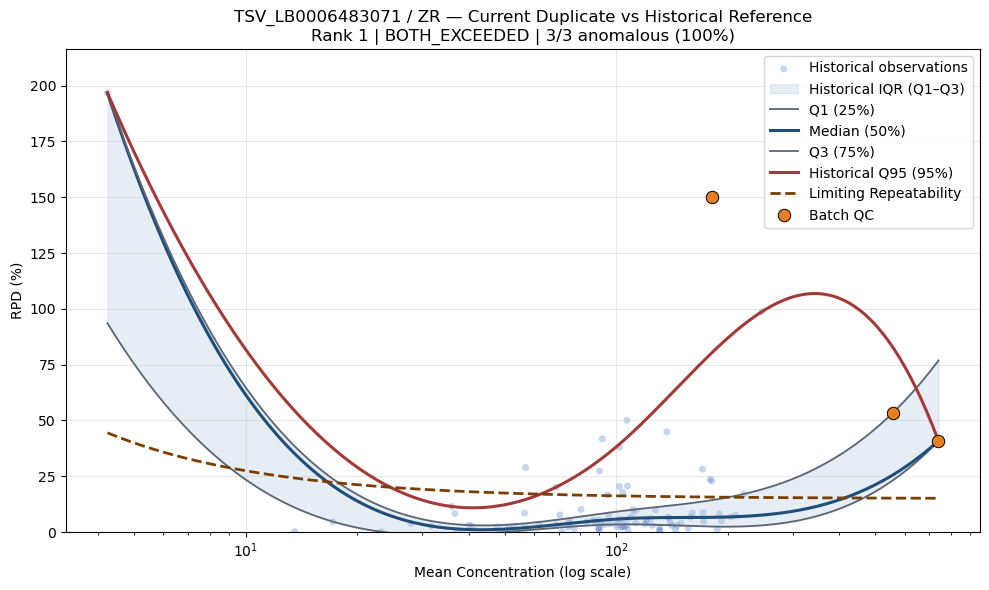

In [51]:
plot_dup_candidate(
    job_code=dup_anomaly_summary_df.iloc[0]["JOB_CODE"],
    analyte_code=dup_anomaly_summary_df.iloc[0]["ANALYTE_CODE"]
)


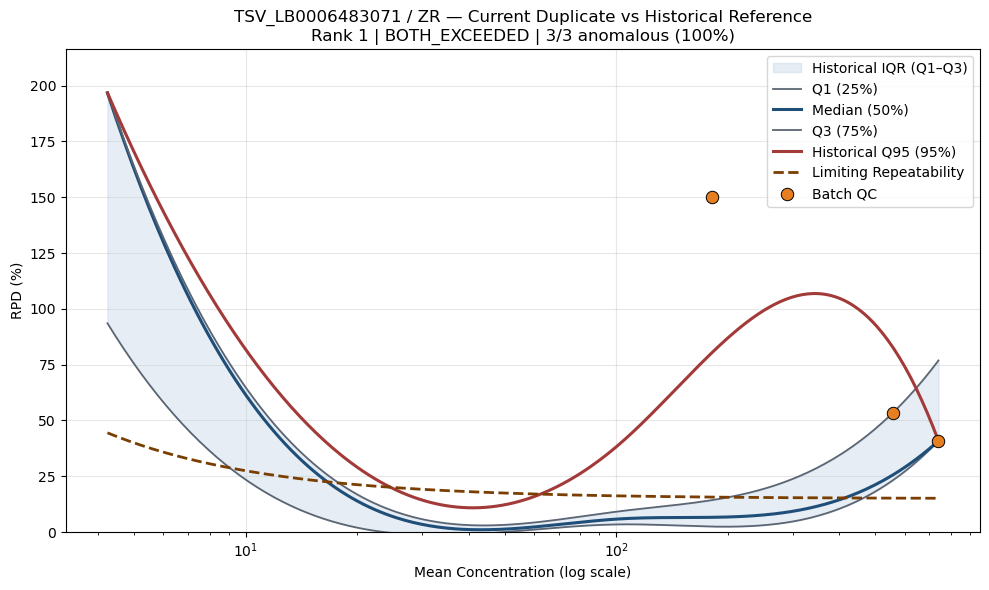

In [52]:
# Run without historical reference data points.
plot_dup_candidate(
    job_code=dup_anomaly_summary_df.iloc[0]["JOB_CODE"],
    analyte_code=dup_anomaly_summary_df.iloc[0]["ANALYTE_CODE"],
    show_historical_observations=False
)


In [53]:
# =============================================================================
# Visualise top-ranked Duplicate anomaly candidates
# =============================================================================

def plot_top_dup_candidates(
    top_n=5,
    show_historical_observations=True
):
    """
    Plot the top-ranked Duplicate Job x Analyte anomaly candidates.

    Parameters
    ----------
    top_n : int, default 5
        Number of ranked Job x Analyte candidates to visualise.

    show_historical_observations : bool, default True
        Passed through to plot_dup_candidate(). When True, original historical
        observations are displayed behind the fitted historical reference model.
    """

    # -------------------------------------------------------------------------
    # Validate requested number of candidates
    # -------------------------------------------------------------------------

    if top_n <= 0:
        print("top_n must be greater than 0.")
        return

    if dup_anomaly_summary_df.empty:
        print("No ranked Duplicate anomaly candidates are available.")
        return

    # Limit requested number to candidates actually available
    plot_count = min(
        top_n,
        len(dup_anomaly_summary_df)
    )

    top_candidates = (
        dup_anomaly_summary_df
        .head(plot_count)
        .copy()
    )

    # -------------------------------------------------------------------------
    # Confirm review set
    # -------------------------------------------------------------------------

    print(
        f"Plotting top {plot_count} of "
        f"{len(dup_anomaly_summary_df):,} ranked "
        f"Job x Analyte anomaly candidates."
    )

    print(
        f"Historical observations displayed: "
        f"{show_historical_observations}"
    )

    # -------------------------------------------------------------------------
    # Generate candidate visualisations in ranking order
    # -------------------------------------------------------------------------

    for _, candidate in top_candidates.iterrows():

        plot_dup_candidate(
            job_code=candidate["JOB_CODE"],
            analyte_code=candidate["ANALYTE_CODE"],
            show_historical_observations=show_historical_observations
        )


Plotting top 5 of 377 ranked Job x Analyte anomaly candidates.
Historical observations displayed: True


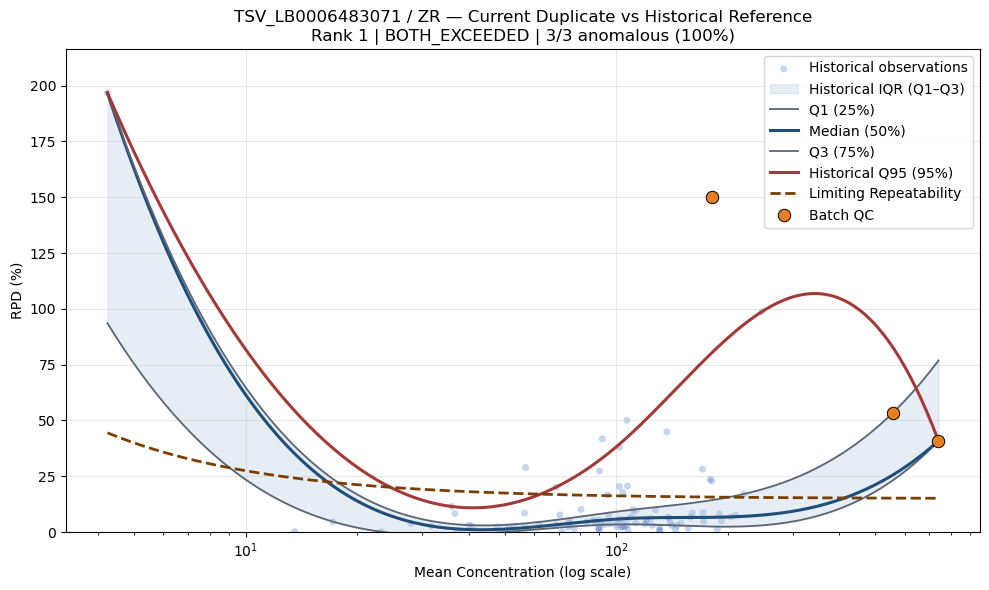

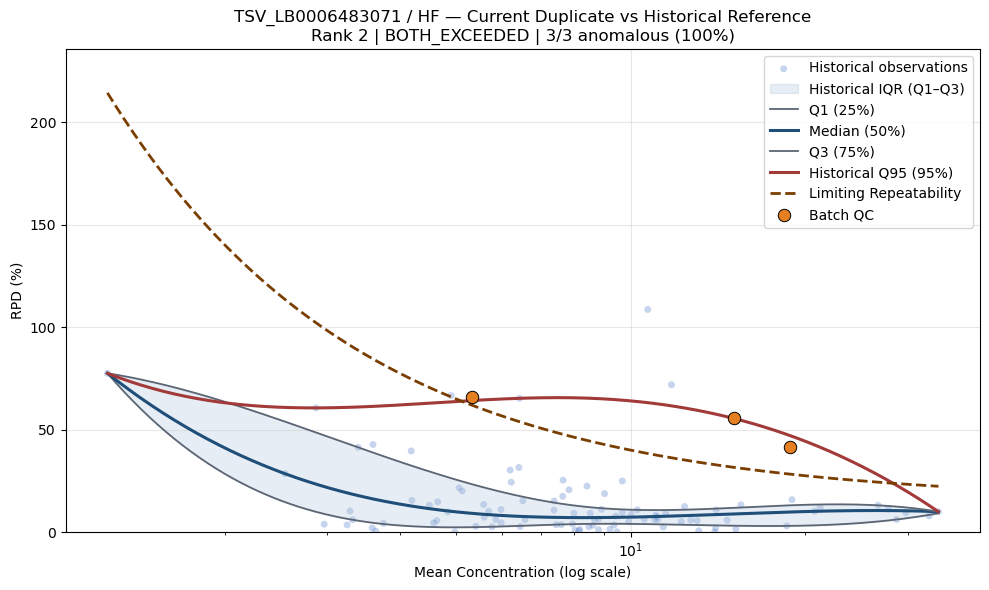

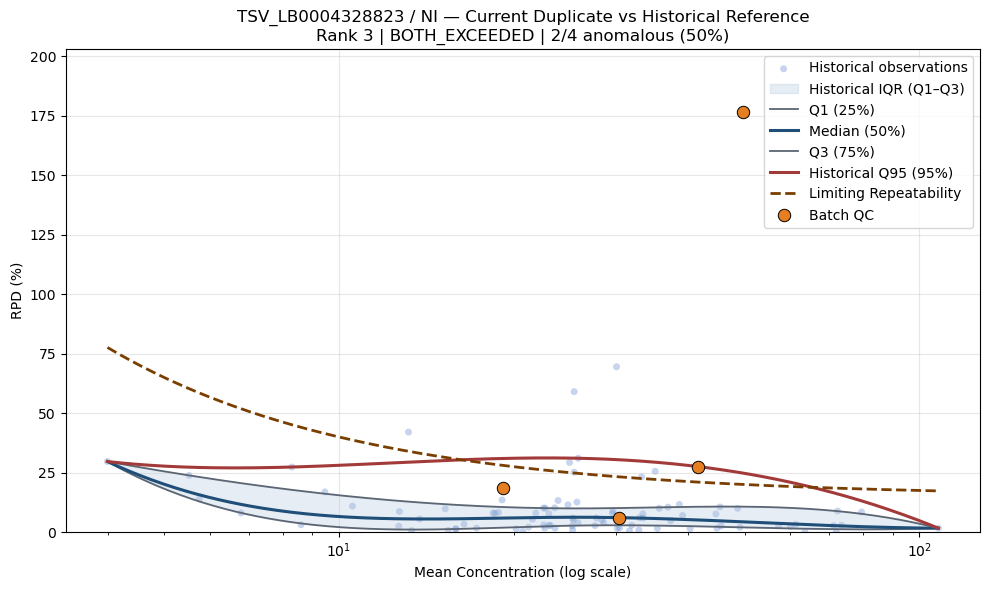

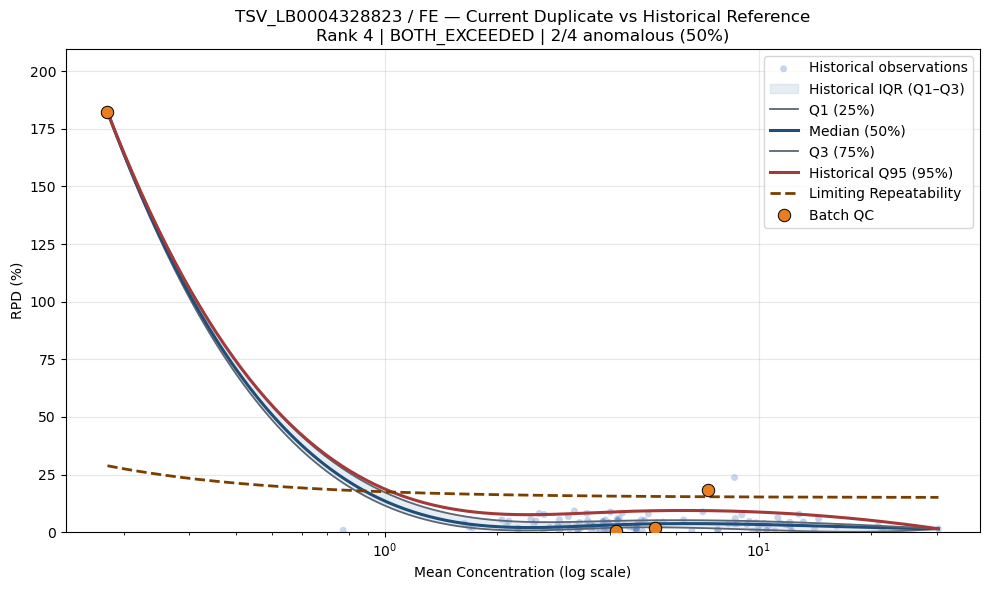

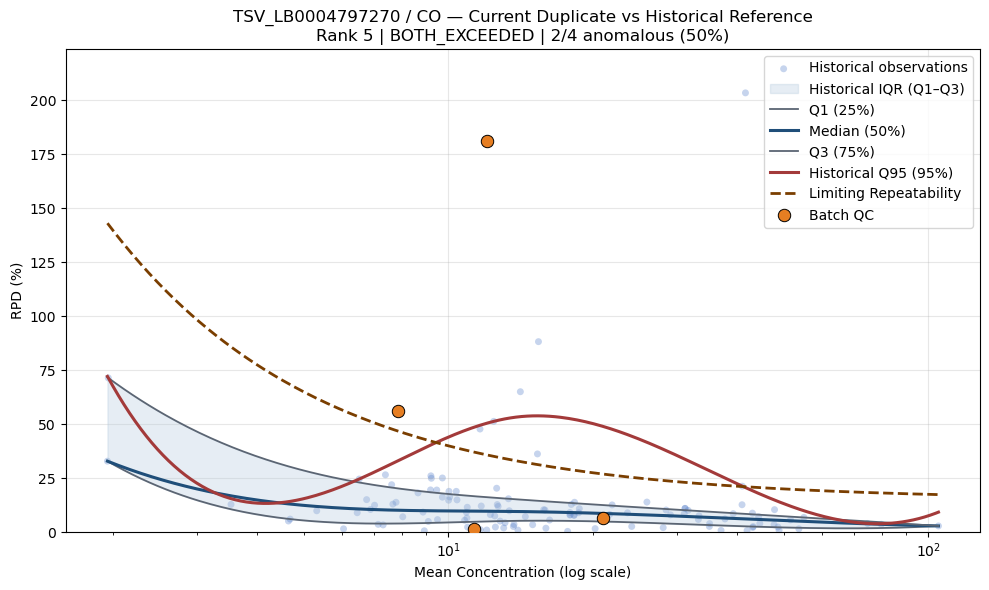

In [54]:
plot_top_dup_candidates(top_n=5)
